In [17]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

#loading data
dataset=load_dataset('lukebarousse/data_jobs')

#converting the loaded dataset into a pandas dataframe
df=dataset['train'].to_pandas()

#formatting datetime
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

#cleaning the job_skills column by converting them from strings into lists
import ast
df['job_skills']=df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills )

In [15]:
#Filtering out Business analyst jobs in the US
df_us=df[(df['job_title_short']=='Business Analyst') & (df['job_country']=='United States')]

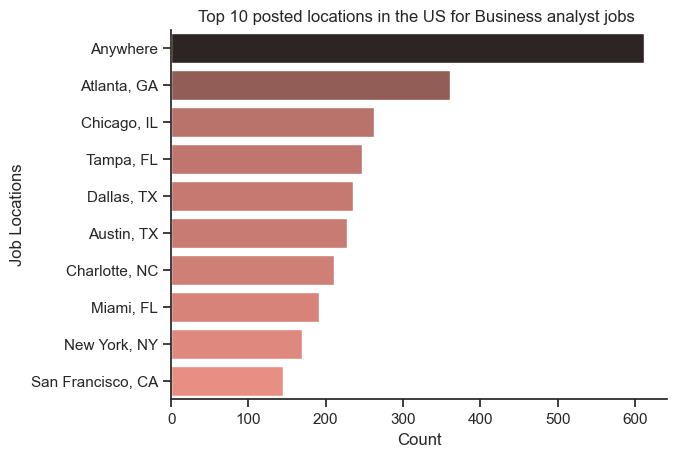

In [ ]:
#creating a bar graph that displays the top 10 most-listed locations in the US for business analyst jobs
df_top_locations=df_us['job_location'].value_counts().head(10).to_frame()
sns.barplot(df_top_locations, x='count', y='job_location', hue='count', palette='dark:salmon_r', legend=False)
sns.set_theme(style='ticks')
sns.despine()
plt.xlabel('Count')
plt.ylabel('Job Locations')
plt.title('Top 10 posted locations in the US for Business analyst jobs ')
plt.show()


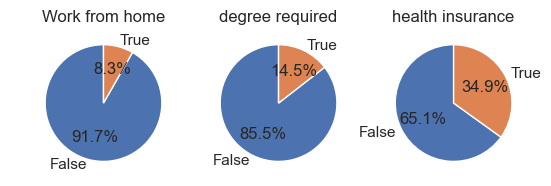

In [42]:
#creating pie charts to demonstrate the % of distribution of work from home jobs, degree requirements, and insurance support
job_categories={'job_work_from_home': 'Work from home',
                'job_no_degree_mention': 'degree required',
                'job_health_insurance' : 'health insurance'}
fig, ax= plt.subplots(1,3)
for i, (column, title) in enumerate(job_categories.items()):
    df_us[column].value_counts().plot(kind='pie', ax=ax[i], startangle=90, autopct='%1.1f%%', labels=[False, True])
    ax[i].set_title(title)
    ax[i].set_ylabel(' ')
plt.show()

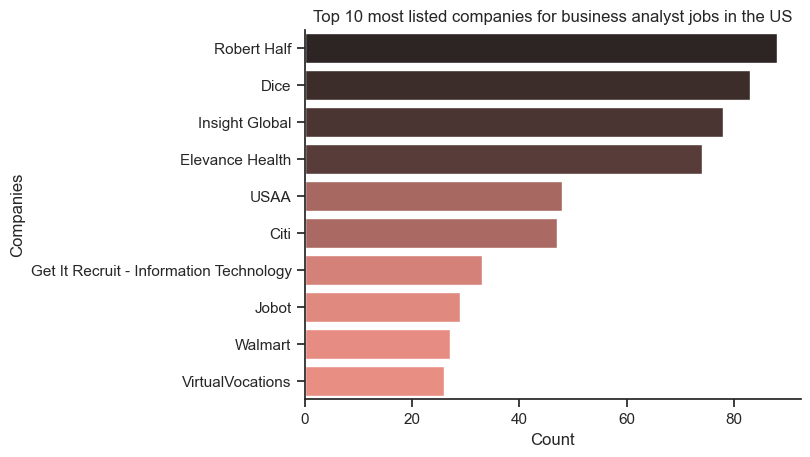

In [48]:
#creating a bar graph that displays the top 10 companies with the most listings
df_top_companies=df_us['company_name'].value_counts().head(10).to_frame()
sns.barplot(df_top_companies, x='count', y='company_name', hue='count', palette='dark:salmon_r', legend=False)
sns.set_theme(style='ticks')
sns.despine()
plt.xlabel('Count')
plt.ylabel('Companies')
plt.title('Top 10 most listed companies for business analyst jobs in the US')
plt.show()
